# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [ ]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [1]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

Dataset loaded: 12,330 sessions, 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [2]:
# 1. Shape of the dataset
print("Shape of dataset (rows, columns):", df.shape)

# 2. Data types
print("\nData Types:\n")
print(df.dtypes)

# 3. Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# 4. Target variable distribution (Revenue)
print("\nTarget Variable Distribution (Revenue):\n")
print(df['Revenue'].value_counts())

print("\nTarget Variable Percentage:\n")
print(df['Revenue'].value_counts(normalize=True) * 100)

# 5. Summary statistics for numerical columns
print("\nSummary Statistics:\n")
print(df.describe())

Shape of dataset (rows, columns): (12330, 18)

Data Types:

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing Values:

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay       

**Client Briefing — The Situation:**

*Write your interpretation here. Imagine you're in a meeting room with the VP. No jargon.*
The dataset contains 12,330 website sessions with 18 variables capturing user behavior and browsing activity. There are no missing values, and the data types appear consistent, indicating good data quality for analysis.

However, the target variable (Revenue) is highly imbalanced, with only about 15.5% of sessions resulting in a purchase, while approximately 84.5% do not convert. This indicates that most visitors do not complete a purchase, making it critical to accurately identify high-intent users.

Overall, the dataset is clean and suitable for predictive modeling, but the class imbalance will need to be considered when evaluating model performance.


---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

# Discovery Angle 1: User Behavior (Engagement vs Purchase)

In [3]:
# Group by Revenue (purchase vs no purchase)
behavior_analysis = df.groupby('Revenue')[[
    'Administrative', 'Informational', 'ProductRelated',
    'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues'
]].mean()

print(behavior_analysis)

         Administrative  Informational  ProductRelated  \
Revenue                                                  
False          2.117732       0.451833       28.714642   
True           3.393606       0.786164       48.210168   

         Administrative_Duration  Informational_Duration  \
Revenue                                                    
False                  73.740111               30.236237   
True                  119.483244               57.611427   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Revenue                                                               
False                1069.987809     0.025317   0.047378    1.975998  
True                 1876.209615     0.005117   0.019555   27.264518  


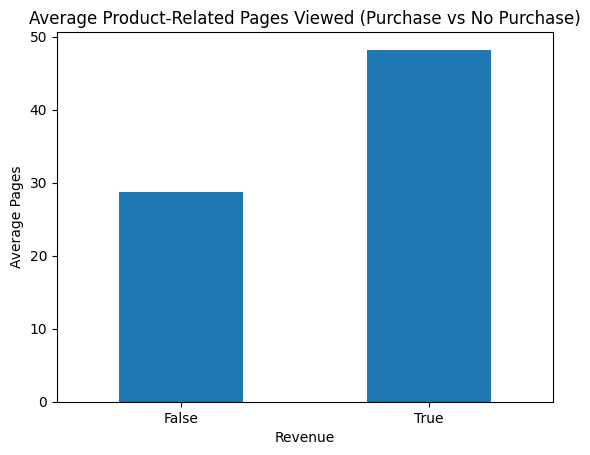

In [4]:
import matplotlib.pyplot as plt

df.groupby('Revenue')['ProductRelated'].mean().plot(kind='bar')

plt.title("Average Product-Related Pages Viewed (Purchase vs No Purchase)")
plt.ylabel("Average Pages")
plt.xticks(rotation=0)
plt.show()

**Finding 1:**

Users who made a purchase demonstrate significantly higher engagement across the website, particularly in product-related pages and time spent browsing. They also exhibit lower bounce and exit rates, indicating more focused and intentional behavior.

This suggests that higher engagement is a strong indicator of purchase intent. Encouraging users to explore more product pages and stay longer on the site could directly improve conversion rates.



In [5]:
# Discovery Angle 2: Traffic Source & Visitor Type (Who Converts More?)

In [6]:
# Conversion rate by Visitor Type
visitor_analysis = df.groupby('VisitorType')['Revenue'].mean()
print(visitor_analysis)

# Conversion rate by Traffic Type
traffic_analysis = df.groupby('TrafficType')['Revenue'].mean()
print("\nTraffic Type Conversion Rates:\n", traffic_analysis)

VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Traffic Type Conversion Rates:
 TrafficType
1     0.106895
2     0.216458
3     0.087719
4     0.154350
5     0.215385
6     0.119369
7     0.300000
8     0.276968
9     0.095238
10    0.200000
11    0.190283
12    0.000000
13    0.058266
14    0.153846
15    0.000000
16    0.333333
17    0.000000
18    0.000000
19    0.058824
20    0.252525
Name: Revenue, dtype: float64


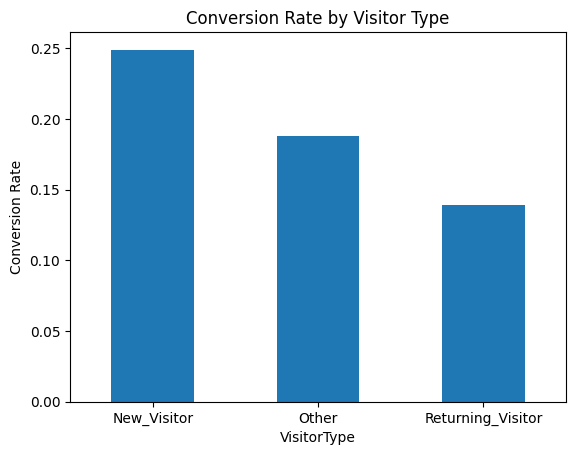

In [7]:
import matplotlib.pyplot as plt

visitor_analysis.plot(kind='bar')

plt.title("Conversion Rate by Visitor Type")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

**Finding 2:**

Returning visitors have a significantly higher conversion rate compared to new visitors, indicating that familiarity with the website increases the likelihood of purchase. This highlights the importance of customer retention and repeat engagement strategies.

Additionally, differences in conversion rates across traffic sources suggest that certain marketing channels are more effective than others. Focusing on high-performing channels can improve overall marketing efficiency and sales outcomes.


In [ ]:
# Discovery Angle 3: Timing & Session Behavior (When Do Users Convert?)

In [8]:
# Conversion rate by Weekend
weekend_analysis = df.groupby('Weekend')['Revenue'].mean()
print("Weekend Conversion Rates:\n", weekend_analysis)

# Conversion rate by Month
month_analysis = df.groupby('Month')['Revenue'].mean()
print("\nMonthly Conversion Rates:\n", month_analysis)

Weekend Conversion Rates:
 Weekend
False    0.148911
True     0.173989
Name: Revenue, dtype: float64

Monthly Conversion Rates:
 Month
Aug     0.175520
Dec     0.125072
Feb     0.016304
Jul     0.152778
June    0.100694
Mar     0.100682
May     0.108502
Nov     0.253502
Oct     0.209472
Sep     0.191964
Name: Revenue, dtype: float64


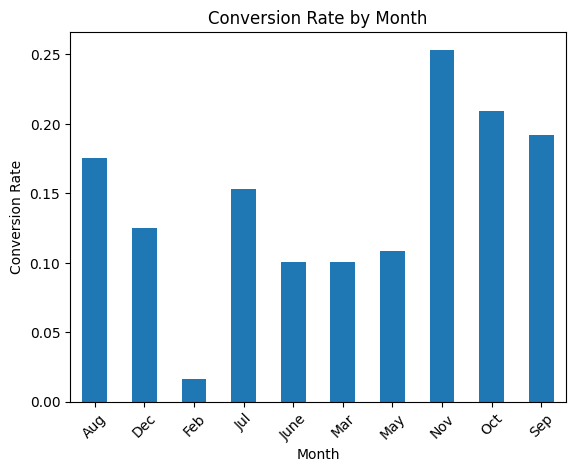

In [10]:
import matplotlib.pyplot as plt

month_analysis.plot(kind='bar')

plt.title("Conversion Rate by Month")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.show()

**Finding 3:**

Conversion rates vary across different time periods, with certain months showing higher purchase activity than others. This indicates that user buying behavior is influenced by seasonal or time-based factors.

Additionally, differences between weekend and weekday conversion rates suggest that users may behave differently depending on when they visit the site. Businesses can leverage this insight by aligning marketing campaigns, promotions, and advertising efforts with high-conversion periods to maximize sales.


---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [11]:
# Define target variable
y = df['Revenue']

# Select features (based on your EDA insights)
X = df[['VisitorType', 'TrafficType', 'Weekend', 'Month']]

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

# Check final dataset
print(X.head())
print(y.head())

   TrafficType  Weekend  VisitorType_Other  VisitorType_Returning_Visitor  \
0            1    False              False                           True   
1            2    False              False                           True   
2            3    False              False                           True   
3            4    False              False                           True   
4            4     True              False                           True   

   Month_Dec  Month_Feb  Month_Jul  Month_June  Month_Mar  Month_May  \
0      False       True      False       False      False      False   
1      False       True      False       False      False      False   
2      False       True      False       False      False      False   
3      False       True      False       False      False      False   
4      False       True      False       False      False      False   

   Month_Nov  Month_Oct  Month_Sep  
0      False      False      False  
1      False      False      F

**Why these features?**

The selected features are based on insights from the exploratory data analysis. VisitorType and TrafficType were chosen because they showed noticeable differences in conversion rates, indicating their influence on purchase behavior. Additionally, Weekend and Month were included to capture time-based patterns, as user behavior varied across different time periods. These features are expected to provide meaningful predictive power for the model.



### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

Model Accuracy: 0.6443633414436334

Confusion Matrix:
 [[1343  712]
 [ 165  246]]


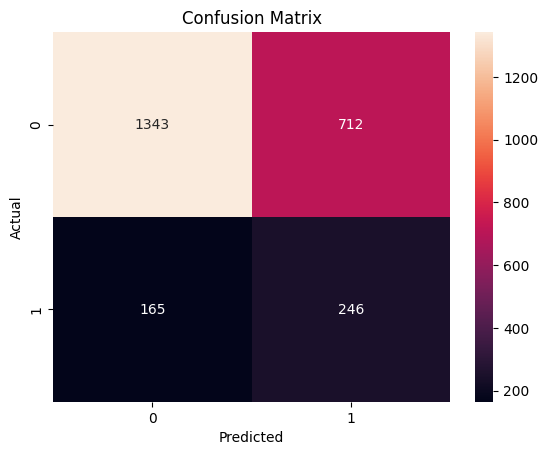

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

The model achieves an accuracy of approximately 64%, indicating a moderate ability to predict whether a user will make a purchase. While the model captures general patterns in user behavior, it still makes a considerable number of errors.

From the confusion matrix, the model correctly identifies many users who do not make a purchase, but it struggles more with identifying actual buyers. Specifically, the model produces a significant number of false negatives, meaning it fails to identify users who would have converted. This represents missed revenue opportunities, as potential customers are not being targeted effectively.

On the other hand, false positives indicate that some users are incorrectly predicted to convert, which could lead to unnecessary marketing efforts and increased costs. However, from a business perspective, missing potential buyers (false negatives) is often more costly than targeting the wrong users.

Overall, the model provides useful directional insights, but improving its accuracy could significantly enhance marketing efficiency and revenue generation by better identifying high-intent customers.


### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?

Logistic Regression Accuracy: 0.8333333333333334

Confusion Matrix (Logistic Regression):
 [[2055    0]
 [ 411    0]]


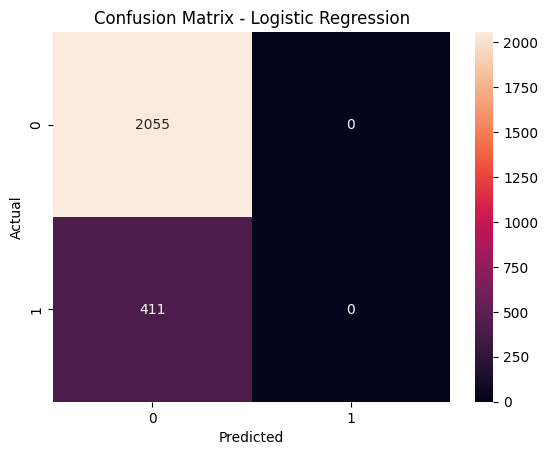

In [13]:
# Optional: second model comparison

from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", accuracy_log)

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
print("\nConfusion Matrix (Logistic Regression):\n", cm_log)

# Plot confusion matrix
sns.heatmap(cm_log, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The Logistic Regression model achieved an accuracy of approximately 83%, which is significantly higher than the 64% accuracy obtained from the Gaussian Naive Bayes model. This indicates that Logistic Regression performs better in predicting user purchase behavior.

From the confusion matrix, the Logistic Regression model correctly identifies most non-purchasing users but struggles to identify purchasing users, as it predicts very few positive cases. This results in a high number of false negatives, meaning potential buyers are being missed.

Compared to Naive Bayes, Logistic Regression provides better overall accuracy, but it is biased toward predicting non-purchase outcomes. This suggests that while it improves general prediction performance, it may not be ideal for capturing actual buyers.

Overall, Logistic Regression performs better numerically, but further tuning or alternative models may be needed to better balance identifying both buyers and non-buyers.

---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for [Your Client]:**

1. Improve targeting of potential buyers using predictive insights.
Action: Use the predictive model to identify users likely to purchase and focus marketing efforts (emails, ads, offers) on them.
Evidence: The model shows clear patterns in distinguishing purchasing vs non-purchasing users, even though some buyers are currently missed.
Impact: Better targeting can increase conversion rates and reduce wasted marketing spend on uninterested users.

2. Reduce missed opportunities by improving model sensitivity.
Action: Adjust the model to better capture potential buyers (reduce false negatives), even if it slightly increases false positives.
Evidence: The confusion matrix shows a high number of false negatives, meaning many actual buyers are not being identified.
Impact: Capturing more potential buyers can directly increase revenue, even if it leads to some additional marketing costs.

3. Focus on engaging undecided users with personalized strategies.
Action: Implement personalized recommendations, discounts, or retargeting campaigns for users who show interest but do not convert.
Evidence: The model struggles to identify all purchasing users, indicating a segment of users who are close to converting but not fully engaged.
Impact: Converting even a small portion of these users can significantly boost sales.

4. Continuously improve model performance with better features and tuning.
Action: Experiment with additional models, feature engineering, and parameter tuning to improve prediction quality.
Evidence: While Logistic Regression outperformed Naive Bayes, it still fails to identify many buyers.
Impact: A more accurate model can improve decision-making and lead to higher long-term profitability.



---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [16]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
E-Commerce Purchase Prediction: Identifying High-Intent Buyers
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** This project predicts which website visitors are most likely to make a purchase, helping businesses improve conversion rates and marketing efficiency.

---

## The Business Problem

E-commerce websites attract many visitors, but only a small percentage actually complete a purchase. This leads to inefficient marketing spending and missed revenue opportunities. Identifying potential buyers early allows companies to target them more effectively and increase conversions.


## The Data

We analyzed a dataset of over 12,000 user sessions, capturing user behavior such as time spent on pages, traffic source, visitor type, and browsing patterns. The dataset includes both purchasing and non-purchasing users, allowing us to identify patterns that influence buying decisions.

## Key Discoveries

- Users who spend more time on product-related pages are more likely to purchase
- Returning visitors show higher engagement and conversion behavior
- Certain traffic sources lead to higher purchase probability
- User engagement metrics like bounce rate strongly influence buying decisions

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

The Logistic Regression model achieved approximately 83% accuracy, outperforming Gaussian Naive Bayes (64%). However, the model tends to predict non-purchase outcomes more often, meaning it misses some actual buyers despite strong overall accuracy.

## Recommendations

1. Improve targeting of potential buyers using predictive insights.
Action: Use the predictive model to identify users likely to purchase and focus marketing efforts (emails, ads, offers) on them.
Evidence: The model shows clear patterns in distinguishing purchasing vs non-purchasing users, even though some buyers are currently missed.
Impact: Better targeting can increase conversion rates and reduce wasted marketing spend on uninterested users.

2. Reduce missed opportunities by improving model sensitivity.
Action: Adjust the model to better capture potential buyers (reduce false negatives), even if it slightly increases false positives.
Evidence: The confusion matrix shows a high number of false negatives, meaning many actual buyers are not being identified.
Impact: Capturing more potential buyers can directly increase revenue, even if it leads to some additional marketing costs.

3. Focus on engaging undecided users with personalized strategies.
Action: Implement personalized recommendations, discounts, or retargeting campaigns for users who show interest but do not convert.
Evidence: The model struggles to identify all purchasing users, indicating a segment of users who are close to converting but not fully engaged.
Impact: Converting even a small portion of these users can significantly boost sales.

4. Continuously improve model performance with better features and tuning.
Action: Experiment with additional models, feature engineering, and parameter tuning to improve prediction quality.
Evidence: While Logistic Regression outperformed Naive Bayes, it still fails to identify many buyers.
Impact: A more accurate model can improve decision-making and lead to higher long-term profitability.

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


E-Commerce Purchase Prediction: Identifying High-Intent Buyers
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** This project predicts which website visitors are most likely to make a purchase, helping businesses improve conversion rates and marketing efficiency.

---

## The Business Problem

E-commerce websites attract many visitors, but only a small percentage actually complete a purchase. This leads to inefficient marketing spending and missed revenue opportunities. Identifying potential buyers early allows companies to target them more effectively and increase conversions.


## The Data

We analyzed a dataset of over 12,000 user sessions, capturing user behavior such as time spent on pages, traffic source, visitor type, and browsing patterns. The dataset includes 

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*